In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#------load data ---------------------------------
purchase = pd.read_csv('../data/QVI_purchase_behaviour (1).csv')

#-----high level checks --------------------------
print("===Purchase Behaviour===")
print(f"shape: {purchase.shape}")
print(purchase.dtypes)
print(purchase.head())
print("\nNull values:\n", purchase.isnull().sum())
print("\nDuplicates:", purchase.duplicated().sum())

print("\nLifestage val counts:\n", purchase['LIFESTAGE'].value_counts())
print("\nPrimium_cx value counts:\n", purchase['PREMIUM_CUSTOMER'].value_counts())

===Purchase Behaviour===
shape: (72637, 3)
LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object
   LYLTY_CARD_NBR               LIFESTAGE PREMIUM_CUSTOMER
0            1000   YOUNG SINGLES/COUPLES          Premium
1            1002   YOUNG SINGLES/COUPLES       Mainstream
2            1003          YOUNG FAMILIES           Budget
3            1004   OLDER SINGLES/COUPLES       Mainstream
4            1005  MIDAGE SINGLES/COUPLES       Mainstream

Null values:
 LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

Duplicates: 0

Lifestage val counts:
 LIFESTAGE
RETIREES                  14805
OLDER SINGLES/COUPLES     14609
YOUNG SINGLES/COUPLES     14441
OLDER FAMILIES             9780
YOUNG FAMILIES             9178
MIDAGE SINGLES/COUPLES     7275
NEW FAMILIES               2549
Name: count, dtype: int64

Primium_cx value counts:
 PREMIUM_CUSTOMER
Mainstream    29245
Budget        24470
Premium       18922
Name: count

In [5]:
%pip install openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open

In [6]:
# ── LOAD TRANSACTION DATA ──────────────────────────────────────────────────

transaction = pd.read_excel('../data/QVI_transaction_data (1).xlsx')
print("=== TRANSACTION DATA ===")
print(f"Shape: {transaction.shape}")
print(transaction.dtypes)
print(transaction.head())
print("\nNull values:\n", transaction.isnull().sum())
print("\nDescriptive stats:\n", transaction.describe())


=== TRANSACTION DATA ===
Shape: (264836, 8)
DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object
    DATE  STORE_NBR  LYLTY_CARD_NBR  TXN_ID  PROD_NBR  \
0  43390          1            1000       1         5   
1  43599          1            1307     348        66   
2  43605          1            1343     383        61   
3  43329          2            2373     974        69   
4  43330          2            2426    1038       108   

                                  PROD_NAME  PROD_QTY  TOT_SALES  
0    Natural Chip        Compny SeaSalt175g         2        6.0  
1                  CCs Nacho Cheese    175g         3        6.3  
2    Smiths Crinkle Cut  Chips Chicken 170g         2        2.9  
3    Smiths Chip Thinly  S/Cream&Onion 175g         5       15.0  
4  Kettle Tortilla ChpsHny&Jlpno Chili 150g         3   

In [7]:
#-------Fixing date col ------------------
transaction['DATE'] = pd.to_datetime(transaction['DATE'], unit='D', origin='1899-12-30')

In [8]:
print("\nDate Range:", transaction['DATE'].min(), "-->", transaction['DATE'].max())


Date Range: 2018-07-01 00:00:00 --> 2019-06-30 00:00:00


In [9]:
#--remove outliers ---------------
## checking for suspiciously large purchase
print("\nTOT_SALES distributioin:\n", transaction['TOT_SALES'].describe())
print("\nPROD_QTY distribution:\n", transaction['PROD_QTY'].describe())


TOT_SALES distributioin:
 count    264836.000000
mean          7.304200
std           3.083226
min           1.500000
25%           5.400000
50%           7.400000
75%           9.200000
max         650.000000
Name: TOT_SALES, dtype: float64

PROD_QTY distribution:
 count    264836.000000
mean          1.907309
std           0.643654
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max         200.000000
Name: PROD_QTY, dtype: float64


In [10]:
#removing non chips buyers and bulk buyers
# eg: qty > 5 in one txn == outliers
transaction = transaction[transaction['PROD_QTY'] <=5]

# -----derive: pack size ----------------------
transaction['PACK_SIZE'] = transaction['PROD_NAME'].str.extract(r'(\d+)g', expand=False).astype(float)
print("\nPACK_SIZE distribution : \n ", transaction['PACK_SIZE'].value_counts().sort_index())


PACK_SIZE distribution : 
  PACK_SIZE
70.0      1507
90.0      3008
110.0    22387
125.0     1454
134.0    25102
135.0     3257
150.0    41633
160.0     2970
165.0    15297
170.0    19983
175.0    64929
180.0     1468
190.0     2995
200.0     4473
210.0     3167
220.0     1564
250.0     3169
270.0     6285
300.0    15166
330.0    12540
380.0     6416
Name: count, dtype: int64


In [11]:
#--- DRIVE: BRAND NAME ----------------
#first word of product name = brand name
transaction['BRAND'] = transaction['PROD_NAME'].str.split().str[0].str.upper()

## standardizing know variants
brand_map = {
    'SNBTS':'SUNBITES',
    'INFZNS': 'INFUZIONS',
    'WW': 'WOOLWORTHS',
    'SMITH':'SMITHS',
    'NCC' : 'NATURALS',
    'DORITO' : 'DORITOS',
    'GRAIN' : 'GRNWVES'
}

transaction['BRAND'] = transaction['BRAND'].replace(brand_map)
print("\nTOP BRANDS:\n", transaction['BRAND'].value_counts().head())


TOP BRANDS:
 BRAND
KETTLE        41288
SMITHS        31823
DORITOS       28145
PRINGLES      25102
WOOLWORTHS    14757
Name: count, dtype: int64


In [12]:
#------- MERGE DATASETS --------------------
df = transaction.merge(purchase, on='LYLTY_CARD_NBR', how='left')
print(f"Merged shape:  {df.shape}")
print(f"Unmatched customers: {df['LIFESTAGE'].isnull().sum()}")

Merged shape:  (264834, 12)
Unmatched customers: 0


In [13]:
df.head(5)

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175.0,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget


SEGMENT METRICES

In [14]:
#------- METRICES BY SEGMENT ----------------------
segment_metrices = df.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg(
    total_customers = ('LYLTY_CARD_NBR', 'nunique'),
    total_sales = ('TOT_SALES', 'sum'),
    total_units = ('PROD_QTY', 'sum'),
    avg_spend_per_txn = ('TOT_SALES', 'mean'),
    num_transactions = ('TXN_ID', 'count'),
).reset_index()

segment_metrices['avg_spend_per_cx'] = (
    segment_metrices['total_sales'] / segment_metrices['total_customers']
)
segment_metrices['avg_units_per_cx'] = (
    segment_metrices['total_units'] / segment_metrices['total_units']
)
segment_metrices['avg_price_per_unit'] = (
    segment_metrices['total_sales'] / segment_metrices['total_units']
)

print(segment_metrices.sort_values('total_sales', ascending=False).to_string())

                 LIFESTAGE PREMIUM_CUSTOMER  total_customers  total_sales  total_units  avg_spend_per_txn  num_transactions  avg_spend_per_cx  avg_units_per_cx  avg_price_per_unit
6           OLDER FAMILIES           Budget             4675    168363.25        45065           7.269570             23160         36.013529               1.0            3.736009
19   YOUNG SINGLES/COUPLES       Mainstream             8088    157621.60        38632           7.558339             20854         19.488328               1.0            4.080079
13                RETIREES       Mainstream             6479    155677.05        40518           7.252262             21466         24.027944               1.0            3.842170
15          YOUNG FAMILIES           Budget             4017    139345.85        37111           7.287201             19122         34.689034               1.0            3.754840
9    OLDER SINGLES/COUPLES           Budget             4929    136769.80        35220           7.4

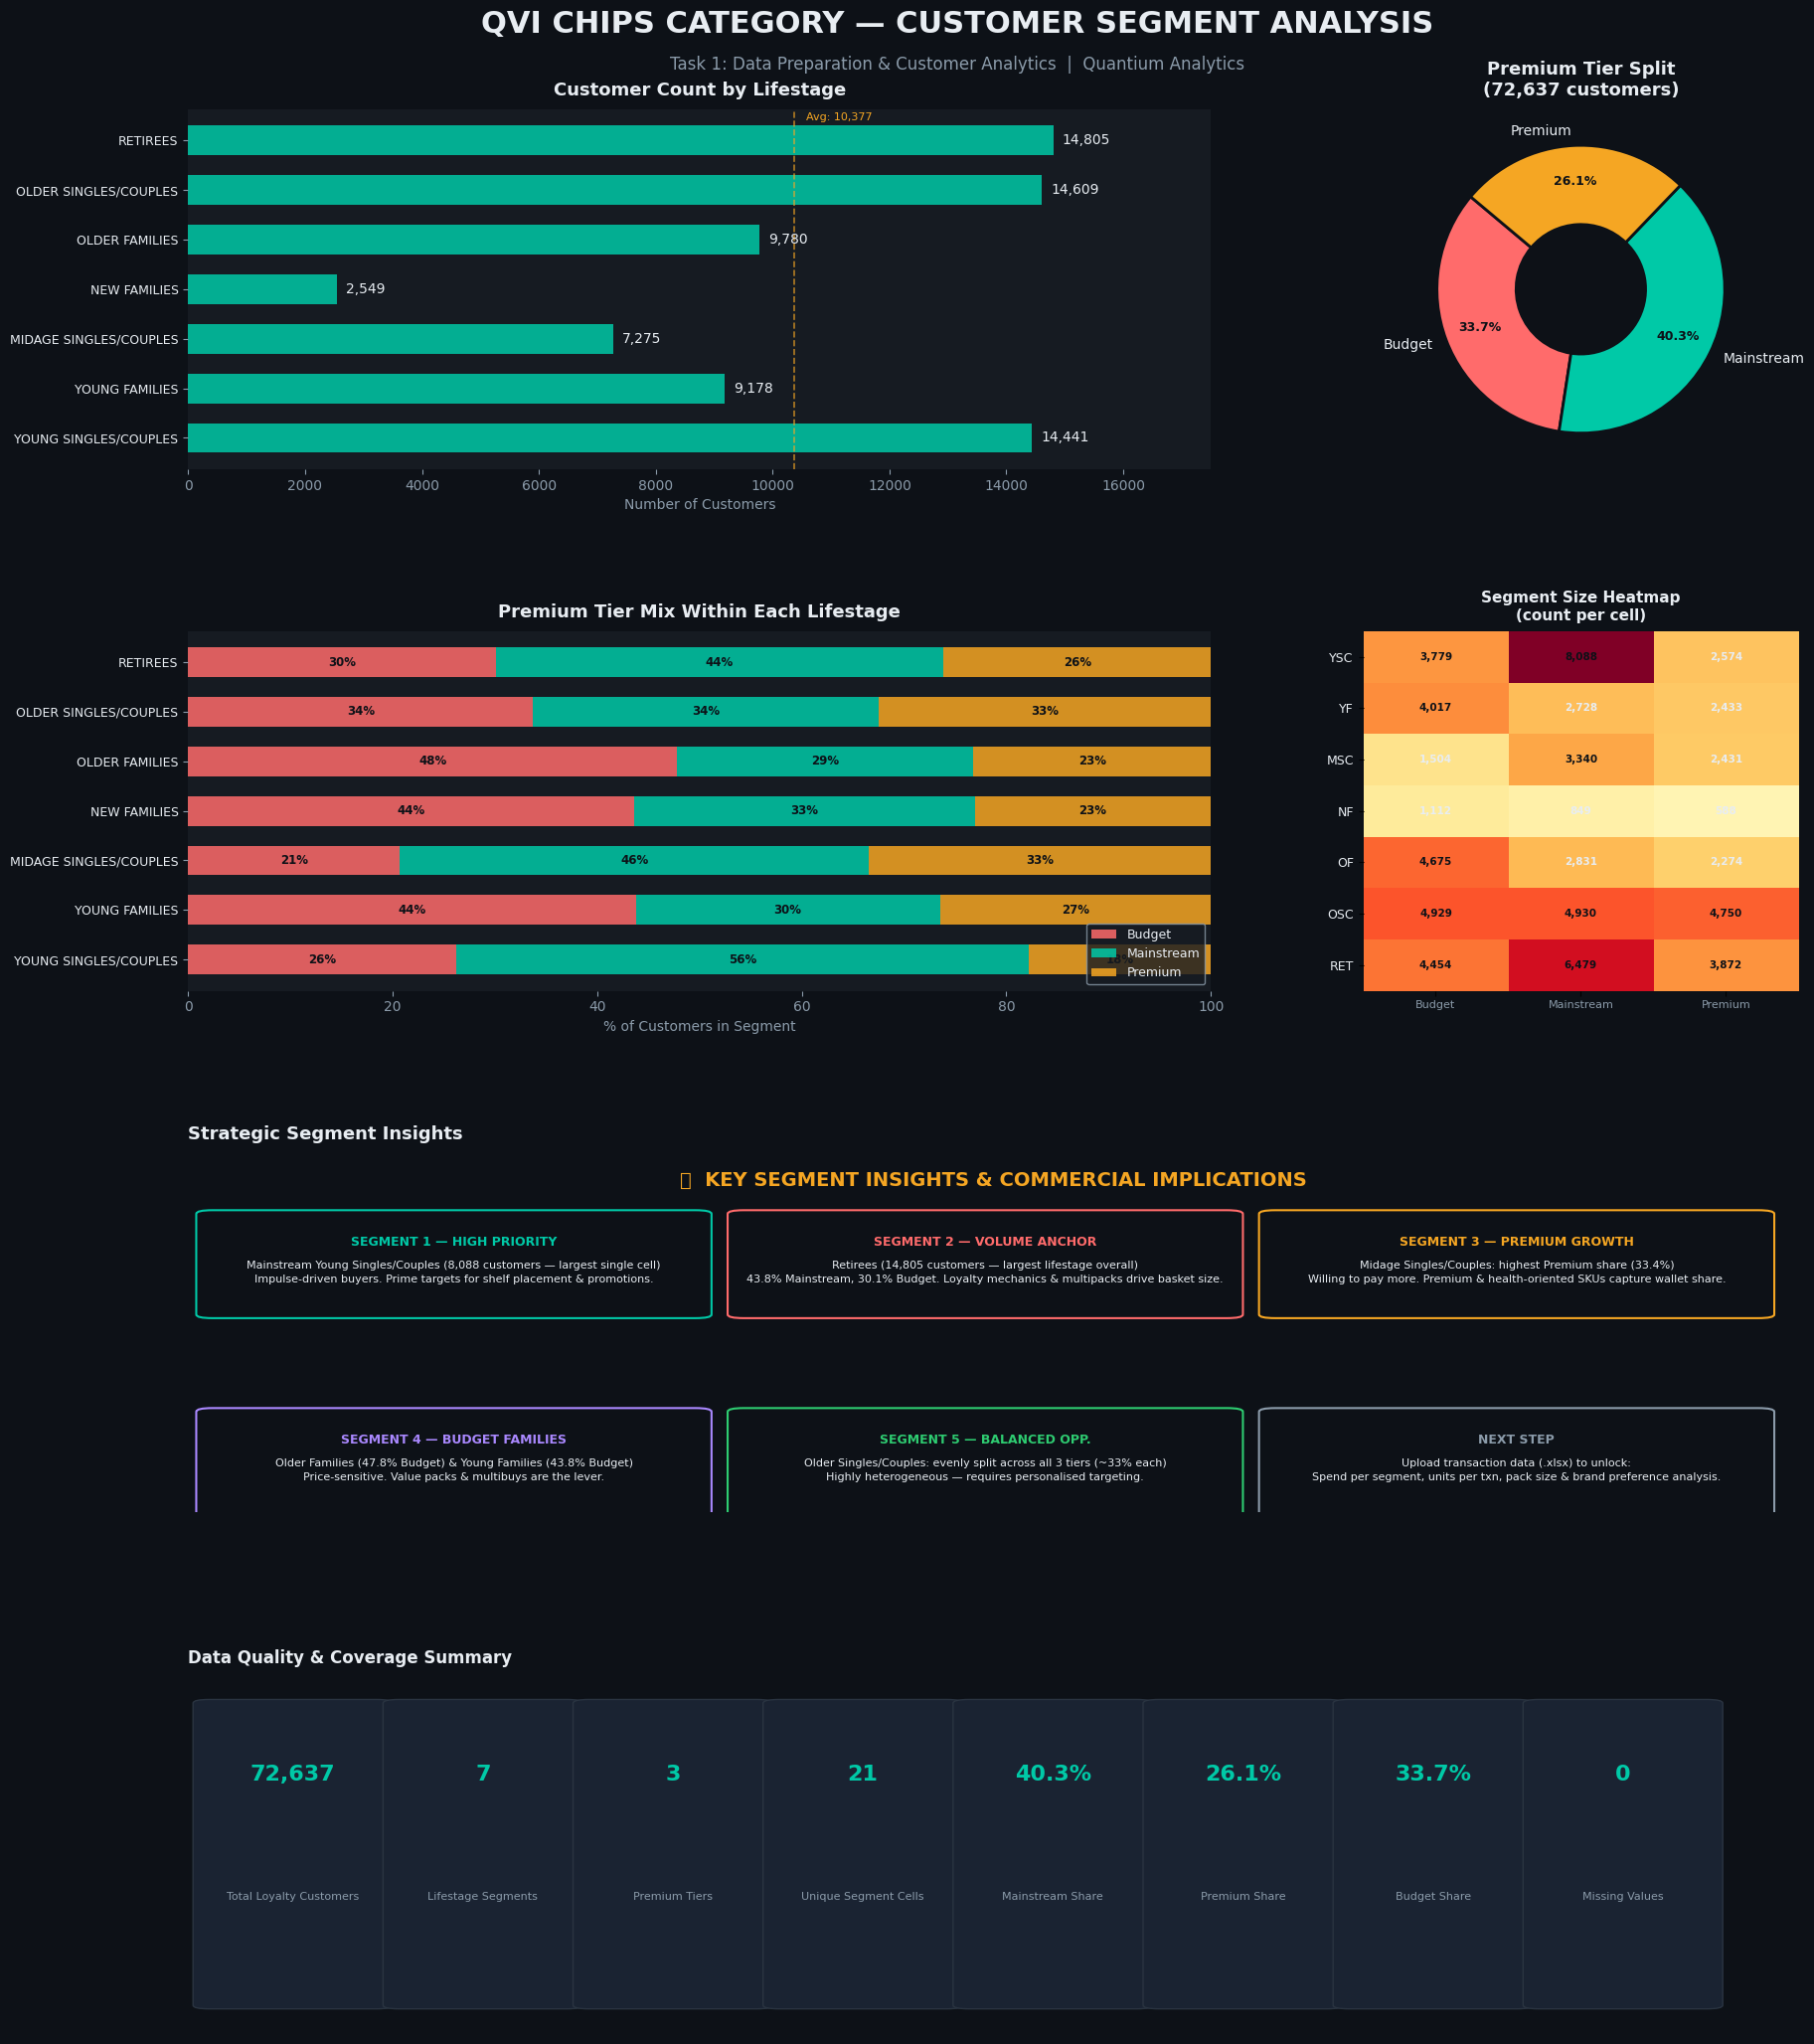

In [15]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── PREP DATA ──────────────────────────────────────────────────────────────
lifestage_order = [
    'YOUNG SINGLES/COUPLES', 'YOUNG FAMILIES', 'MIDAGE SINGLES/COUPLES',
    'NEW FAMILIES', 'OLDER FAMILIES', 'OLDER SINGLES/COUPLES', 'RETIREES'
]
premium_order = ['Budget', 'Mainstream', 'Premium']

seg_counts = purchase.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).size().reset_index(name='COUNT')
seg_pivot  = seg_counts.pivot(index='LIFESTAGE', columns='PREMIUM_CUSTOMER', values='COUNT').fillna(0)
seg_pivot  = seg_pivot.reindex(lifestage_order)[premium_order]
seg_pct    = seg_pivot.div(seg_pivot.sum(axis=1), axis=0) * 100

lifestage_total = purchase['LIFESTAGE'].value_counts().reindex(lifestage_order)
premium_total   = purchase['PREMIUM_CUSTOMER'].value_counts().reindex(premium_order)

# ── COLOUR PALETTE ─────────────────────────────────────────────────────────
GOLD     = '#F5A623'
TEAL     = '#00C9A7'
CORAL    = '#FF6B6B'
GREEN    = '#2ECC71'
LIGHT    = '#E8EDF2'
DIM      = '#8B9BAA'
CARD_BG  = '#161B22'
BG       = '#0D1117'
colors_premium = [CORAL, TEAL, GOLD]

# ── BUILD FIGURE ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 22), facecolor=BG)
gs  = GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35,
               left=0.07, right=0.97, top=0.93, bottom=0.05)

fig.text(0.5, 0.965, 'QVI CHIPS CATEGORY — CUSTOMER SEGMENT ANALYSIS',
         ha='center', fontsize=22, fontweight='bold', color=LIGHT)
fig.text(0.5, 0.948, 'Task 1: Data Preparation & Customer Analytics  |  Quantium Analytics',
         ha='center', fontsize=12, color=DIM)

# ── CHART 1: Horizontal bar — customer count by lifestage ──────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(CARD_BG)
bars = ax1.barh(lifestage_order, lifestage_total[lifestage_order],
                color=TEAL, alpha=0.85, height=0.6)
for bar, val in zip(bars, lifestage_total[lifestage_order]):
    ax1.text(val + 150, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=10, color=LIGHT)
ax1.axvline(lifestage_total.mean(), color=GOLD, linestyle='--', alpha=0.7, linewidth=1.2)
ax1.text(lifestage_total.mean() + 200, 6.4,
         f"Avg: {lifestage_total.mean():,.0f}", color=GOLD, fontsize=8)
ax1.set_xlabel('Number of Customers', color=DIM, fontsize=10)
ax1.set_title('Customer Count by Lifestage', color=LIGHT, fontsize=13, fontweight='bold', pad=10)
ax1.tick_params(colors=DIM)
ax1.spines[:].set_visible(False)
ax1.set_xlim(0, 17500)
for lbl in ax1.get_yticklabels():
    lbl.set_color(LIGHT); lbl.set_fontsize(9)

# ── CHART 2: Donut — premium tier split ───────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(CARD_BG)
wedges, texts, autotexts = ax2.pie(
    premium_total.values, labels=premium_order, colors=colors_premium,
    autopct='%1.1f%%', startangle=140, pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2)
)
for t in texts:     t.set_color(LIGHT); t.set_fontsize(10)
for at in autotexts: at.set_color(BG);  at.set_fontsize(9); at.set_fontweight('bold')
ax2.set_title('Premium Tier Split\n(72,637 customers)',
              color=LIGHT, fontsize=13, fontweight='bold', pad=10)

# ── CHART 3: Stacked bar — premium mix by lifestage ───────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(CARD_BG)
bottom_vals = np.zeros(len(lifestage_order))
for tier, color in zip(premium_order, colors_premium):
    vals = seg_pct[tier].values
    ax3.barh(lifestage_order, vals, left=bottom_vals,
             color=color, alpha=0.85, height=0.6, label=tier)
    for j, (v, b) in enumerate(zip(vals, bottom_vals)):
        if v > 8:
            ax3.text(b + v / 2, j, f'{v:.0f}%',
                     ha='center', va='center', fontsize=8.5,
                     color=BG, fontweight='bold')
    bottom_vals += vals
ax3.set_xlim(0, 100)
ax3.set_xlabel('% of Customers in Segment', color=DIM, fontsize=10)
ax3.set_title('Premium Tier Mix Within Each Lifestage',
              color=LIGHT, fontsize=13, fontweight='bold', pad=10)
ax3.legend(loc='lower right', facecolor=CARD_BG, edgecolor=DIM,
           labelcolor=LIGHT, fontsize=9)
ax3.tick_params(colors=DIM)
ax3.spines[:].set_visible(False)
for lbl in ax3.get_yticklabels():
    lbl.set_color(LIGHT); lbl.set_fontsize(9)

# ── CHART 4: Heatmap — segment sizes ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.set_facecolor(CARD_BG)
data_norm = seg_pivot.values / seg_pivot.values.max()
ax4.imshow(data_norm, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
ax4.set_xticks(range(3))
ax4.set_xticklabels(['Budget', 'Mainstream', 'Premium'], color=DIM, fontsize=8)
ax4.set_yticks(range(7))
ax4.set_yticklabels(['YSC', 'YF', 'MSC', 'NF', 'OF', 'OSC', 'RET'],
                    color=LIGHT, fontsize=9)
for i in range(7):
    for j in range(3):
        val = int(seg_pivot.values[i, j])
        ax4.text(j, i, f'{val:,}', ha='center', va='center', fontsize=7.5,
                 color=BG if data_norm[i, j] > 0.4 else LIGHT, fontweight='bold')
ax4.set_title('Segment Size Heatmap\n(count per cell)',
              color=LIGHT, fontsize=11, fontweight='bold', pad=8)
ax4.spines[:].set_visible(False)

# ── PANEL: Strategic insights ─────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, :])
ax5.set_facecolor(CARD_BG)
ax5.axis('off')
ax5.text(0.5, 0.95, '🔍  KEY SEGMENT INSIGHTS & COMMERCIAL IMPLICATIONS',
         transform=ax5.transAxes, ha='center', fontsize=14,
         fontweight='bold', color=GOLD, va='top')

insights = [
    ("SEGMENT 1 — HIGH PRIORITY", TEAL,
     "Mainstream Young Singles/Couples (8,088 customers — largest single cell)\nImpulse-driven buyers. Prime targets for shelf placement & promotions.",
     0.01, 0.7),
    ("SEGMENT 2 — VOLUME ANCHOR", CORAL,
     "Retirees (14,805 customers — largest lifestage overall)\n43.8% Mainstream, 30.1% Budget. Loyalty mechanics & multipacks drive basket size.",
     0.34, 0.7),
    ("SEGMENT 3 — PREMIUM GROWTH", GOLD,
     "Midage Singles/Couples: highest Premium share (33.4%)\nWilling to pay more. Premium & health-oriented SKUs capture wallet share.",
     0.67, 0.7),
    ("SEGMENT 4 — BUDGET FAMILIES", '#AA88FF',
     "Older Families (47.8% Budget) & Young Families (43.8% Budget)\nPrice-sensitive. Value packs & multibuys are the lever.",
     0.01, 0.15),
    ("SEGMENT 5 — BALANCED OPP.", GREEN,
     "Older Singles/Couples: evenly split across all 3 tiers (~33% each)\nHighly heterogeneous — requires personalised targeting.",
     0.34, 0.15),
    ("NEXT STEP", DIM,
     "Upload transaction data (.xlsx) to unlock:\nSpend per segment, units per txn, pack size & brand preference analysis.",
     0.67, 0.15),
]

for title, color, body, x, y in insights:
    rect = mpatches.FancyBboxPatch(
        (x + 0.005, y - 0.15), 0.30, 0.28,
        boxstyle="round,pad=0.01", linewidth=1.5,
        edgecolor=color, facecolor=BG, transform=ax5.transAxes
    )
    ax5.add_patch(rect)
    ax5.text(x + 0.155, y + 0.07, title, transform=ax5.transAxes,
             ha='center', fontsize=9, fontweight='bold', color=color, va='top')
    ax5.text(x + 0.155, y, body, transform=ax5.transAxes,
             ha='center', fontsize=8, color=LIGHT, va='top', linespacing=1.5)

ax5.set_title('Strategic Segment Insights', color=LIGHT, fontsize=13,
              fontweight='bold', pad=10, loc='left')

# ── METRICS SUMMARY ROW ───────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
ax6.set_facecolor(CARD_BG)
ax6.axis('off')

metrics = [
    ("72,637", "Total Loyalty Customers"),
    ("7",      "Lifestage Segments"),
    ("3",      "Premium Tiers"),
    ("21",     "Unique Segment Cells"),
    ("40.3%",  "Mainstream Share"),
    ("26.1%",  "Premium Share"),
    ("33.7%",  "Budget Share"),
    ("0",      "Missing Values"),
]

for i, (val, label) in enumerate(metrics):
    xpos = 0.065 + i * 0.118
    rect = mpatches.FancyBboxPatch(
        (xpos - 0.052, 0.08), 0.104, 0.84,
        boxstyle="round,pad=0.01", linewidth=1,
        edgecolor='#2A3441', facecolor='#1A2332', transform=ax6.transAxes
    )
    ax6.add_patch(rect)
    ax6.text(xpos, 0.72, val, transform=ax6.transAxes,
             ha='center', fontsize=16, fontweight='bold', color=TEAL, va='center')
    ax6.text(xpos, 0.38, label, transform=ax6.transAxes,
             ha='center', fontsize=8, color=DIM, va='center')

ax6.set_title('Data Quality & Coverage Summary', color=LIGHT, fontsize=12,
              fontweight='bold', pad=8, loc='left')

plt.savefig('QVI_dashboard.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()